In [1]:
import tensorflow as tf
import numpy as np

In [2]:
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical
mnist = datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [3]:
train_x.shape

(60000, 28, 28)

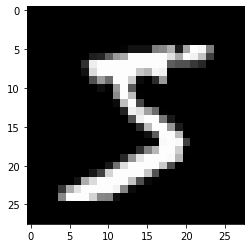

In [5]:
import matplotlib.pyplot as plt
plt.imshow(train_x[0], cmap='gray')

In [6]:
train_x = train_x.reshape(-1,784) 
test_x = test_x.reshape(-1,784) 


In [7]:
train_x = train_x / 255
test_x = test_x / 255

In [8]:
train_y_onehot = to_categorical(train_y)
test_y_onehot = to_categorical(test_y)
train_y_onehot[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [9]:

#Hidden Layer 추가
from tensorflow.keras import layers
model = tf.keras.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=784))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(train_x, train_y_onehot, batch_size = 100, epochs=5)

Epoch 1/5
600/600 [==============================] - 3s 2ms/step - loss: 1.0428 - accuracy: 0.7509
Epoch 2/5
600/600 [==============================] - 1s 2ms/step - loss: 0.4170 - accuracy: 0.8869
Epoch 3/5
600/600 [==============================] - 1s 2ms/step - loss: 0.3411 - accuracy: 0.9038
Epoch 4/5
600/600 [==============================] - 1s 2ms/step - loss: 0.3045 - accuracy: 0.9134
Epoch 5/5
600/600 [==============================] - 1s 2ms/step - loss: 0.2795 - accuracy: 0.9202


In [10]:
# adam 옵티마이저 사용
from tensorflow.keras import layers
model = tf.keras.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=784))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(train_x, train_y_onehot, batch_size = 100, epochs=5)

Epoch 1/5
600/600 [==============================] - 2s 2ms/step - loss: 0.2423 - accuracy: 0.9297
Epoch 2/5
600/600 [==============================] - 1s 2ms/step - loss: 0.0927 - accuracy: 0.9722
Epoch 3/5
600/600 [==============================] - 1s 2ms/step - loss: 0.0598 - accuracy: 0.9818
Epoch 4/5
600/600 [==============================] - 1s 2ms/step - loss: 0.0436 - accuracy: 0.9864
Epoch 5/5
600/600 [==============================] - 1s 2ms/step - loss: 0.0342 - accuracy: 0.9892


In [ ]:
# adam 옵티마이저 + He init.
from tensorflow.keras import layers
model = tf.keras.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=784, kernel_initializer='he_normal'))
model.add(layers.Dense(256, activation='relu', kernel_initializer='he_normal'))
model.add(layers.Dense(10, activation='softmax', kernel_initializer='he_normal'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(train_x, train_y_onehot, batch_size = 100, epochs=5)


Epoch 1/5
600/600 [==============================] - 3s 4ms/step - loss: 0.2372 - accuracy: 0.9300
Epoch 2/5
600/600 [==============================] - 2s 4ms/step - loss: 0.0884 - accuracy: 0.9733
Epoch 3/5
600/600 [==============================] - 2s 4ms/step - loss: 0.0590 - accuracy: 0.9818
Epoch 4/5
600/600 [==============================] - 2s 4ms/step - loss: 0.0417 - accuracy: 0.9867
Epoch 5/5
600/600 [==============================] - 2s 4ms/step - loss: 0.0309 - accuracy: 0.9899


In [ ]:
# adam optimizer와 He 초기화 방법, 드롭아웃 추가
from tensorflow.keras import layers
model = tf.keras.Sequential()
model.add(layers.Dense(256, activation='relu', kernel_initializer='he_normal', input_dim=784))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(256, activation='relu', kernel_initializer='he_normal'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(train_x, train_y_onehot, batch_size = 100, epochs=10)

Epoch 1/10
600/600 [==============================] - 3s 4ms/step - loss: 0.3389 - accuracy: 0.8964
Epoch 2/10
600/600 [==============================] - 2s 4ms/step - loss: 0.1512 - accuracy: 0.9534
Epoch 3/10
600/600 [==============================] - 2s 4ms/step - loss: 0.1141 - accuracy: 0.9656
Epoch 4/10
600/600 [==============================] - 2s 4ms/step - loss: 0.0942 - accuracy: 0.9711
Epoch 5/10
600/600 [==============================] - 2s 4ms/step - loss: 0.0788 - accuracy: 0.9756
Epoch 6/10
600/600 [==============================] - 2s 4ms/step - loss: 0.0701 - accuracy: 0.9776
Epoch 7/10
600/600 [==============================] - 2s 4ms/step - loss: 0.0655 - accuracy: 0.9785
Epoch 8/10
600/600 [==============================] - 2s 4ms/step - loss: 0.0570 - accuracy: 0.9810
Epoch 9/10
600/600 [==============================] - 2s 4ms/step - loss: 0.0521 - accuracy: 0.9832
Epoch 10/10
600/600 [==============================] - 2s 4ms/step - loss: 0.0490 - accuracy: 0.9840

In [ ]:
model.evaluate(test_x, test_y_onehot)

313/313 [==============================] - 1s 3ms/step - loss: 0.0699 - accuracy: 0.9795


[0.0698910802602768, 0.9794999957084656]

In [ ]:
# 오버피팅 상황 만들기
from tensorflow.keras import layers
model = tf.keras.Sequential()
model.add(layers.Dense(512, activation='relu', input_dim=784))

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(train_x, train_y_onehot, batch_size = 100, epochs=5)

Epoch 1/5
600/600 [==============================] - 5s 8ms/step - loss: 0.2718 - accuracy: 0.9186
Epoch 2/5
600/600 [==============================] - 5s 8ms/step - loss: 0.1233 - accuracy: 0.9679
Epoch 3/5
600/600 [==============================] - 5s 8ms/step - loss: 0.0937 - accuracy: 0.9755
Epoch 4/5
600/600 [==============================] - 5s 8ms/step - loss: 0.0755 - accuracy: 0.9803
Epoch 5/5
600/600 [==============================] - 5s 8ms/step - loss: 0.0684 - accuracy: 0.9822


In [ ]:
model.evaluate(test_x, test_y_onehot)

313/313 [==============================] - 1s 4ms/step - loss: 0.1155 - accuracy: 0.9710


[0.11547444015741348, 0.9710000157356262]

In [ ]:
model.save("test.h5")

In [ ]:
!ls 


sample_data  test.h5


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical

mnist = datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()
train_x = train_x.reshape(-1,784) 
test_x = test_x.reshape(-1,784)
train_x = train_x / 255
test_x = test_x / 255
train_y_onehot = to_categorical(train_y)
test_y_onehot = to_categorical(test_y)
train_y_onehot[0]

model = tf.keras.models.load_model('test.h5')
model.evaluate(test_x, test_y_onehot)

313/313 [==============================] - 2s 4ms/step - loss: 0.0944 - accuracy: 0.9771


[0.09438754618167877, 0.9771000146865845]

In [ ]:
from google.colab import files
files.download('test.h5') 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>